# RAW vs PROCESSED — preprocessing comparison

This notebook evaluates the **existing** Stage-2 preprocessing layer. It adds no preprocessing logic of its own:

* raw files are read with `preprocessing.preprocess.scan_raw`, processed files are the Parquet outputs in `processed/`;
* every intermediate representation is recomputed with the pipeline's own expressions in `preprocessing.transforms`;
* integrity checks call `preprocessing.validate`; stage-level collision tables come from the pipeline's `results/*.csv`
  (full data, produced by `preprocessing.measure`).

Only analysis happens here. There is no candidate generation, similarity search, embedding, model or matching decision.
All full-data statistics use Polars lazy scans with the streaming engine, one file at a time. Row-level work uses
deterministic hash samples. Outputs go to `preprocessing/results/comparison/`.

**Representations compared** (names; addresses analogous)

| stage | column | produced by |
|---|---|---|
| raw | `business_name_raw` | original TSV value |
| unicode | *(not stored)* | `T.unicode_stage` |
| lowercase | *(not stored)* | `T.lowercase_stage` |
| norm | `name_norm` | + `T.whitespace_stage` |
| clean | `name_clean` / `name_tokens` | + `T.punctuation_stage` (addresses also drop placeholder segments) |
| fold | *(on demand)* | `T.fold_diacritics(name_clean)` |
| base | `name_base` | `name_clean` without legal-form tokens |

## 0. Setup

In [1]:
import sys, time, warnings
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE.parents[1] if HERE.name == "notebooks" else HERE      # .../student_resource
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from preprocessing import config as C, transforms as T, validate as V
from preprocessing.preprocess import scan_raw

T0 = time.time()
OUT = C.RESULTS_DIR / "comparison"
OUT.mkdir(parents=True, exist_ok=True)
FILES = [(sp, s) for sp in C.SPLITS for s in C.SOURCES]
SEED = C.SEED

pl.Config.set_tbl_rows(60); pl.Config.set_tbl_cols(30); pl.Config.set_fmt_str_lengths(90)
pl.Config.set_tbl_width_chars(260); pl.Config.set_tbl_hide_dataframe_shape(True)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
print("polars", pl.__version__, "| root", ROOT)
print("processed:", sorted(p.name for p in C.PROCESSED_DIR.glob("*.parquet")))

polars 1.44.2 | root C:\Users\rocks\Downloads\6ab10eb3b23ba_student_resource\student_resource
processed: ['test_source1.parquet', 'test_source2.parquet', 'test_source3.parquet', 'train_ground_truth.parquet', 'train_source1.parquet', 'train_source2.parquet', 'train_source3.parquet']


In [2]:
def proc(split, source) -> pl.LazyFrame:
    return pl.scan_parquet(C.processed_path(split, source))


def collect(lf: pl.LazyFrame) -> pl.DataFrame:
    return lf.collect(engine="streaming")


def per_file(query, files=FILES) -> pl.DataFrame:
    '''Run query(split, source) -> LazyFrame for each file separately (bounded memory) and stack results.'''
    return pl.concat([collect(query(sp, s)) for sp, s in files], how="vertical_relaxed")


def order(df: pl.DataFrame) -> pl.DataFrame:
    keys = []
    if "split" in df.columns:
        keys.append(pl.col("split").replace_strict({"train": 0, "test": 1}, default=9, return_dtype=pl.Int8))
    keys += [c for c in ("source", "country", "field") if c in df.columns]
    return df.sort(keys) if keys else df


def save(df: pl.DataFrame, name: str) -> pl.DataFrame:
    df.write_csv(OUT / f"{name}.csv")
    return df


def save_fig(fig, name: str):
    fig.savefig(OUT / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()


def pct(expr) -> pl.Expr:
    return (expr.fill_null(False).mean() * 100).round(3)


def existing(name: str) -> pl.DataFrame:
    '''A table written by the pipeline run (preprocessing/results/<name>.csv).'''
    return pl.read_csv(C.RESULTS_DIR / f"{name}.csv", infer_schema_length=10000)


# Stage expressions, all taken from the pipeline (no new preprocessing logic)
NAME_STAGES = {
    "raw": pl.col("business_name_raw"),
    "unicode": T.unicode_stage("business_name_raw"),
    "lowercase": T.lowercase_stage(T.unicode_stage("business_name_raw")),
    "norm": pl.col("name_norm"),
    "clean": pl.col("name_clean"),
    "fold": T.fold_diacritics("name_clean"),
    "base": pl.col("name_base"),
}
ADDR_STAGES = {
    "raw": pl.col("business_address_raw"),
    "unicode": T.unicode_stage("business_address_raw"),
    "lowercase": T.lowercase_stage(T.unicode_stage("business_address_raw")),
    "norm": pl.col("address_norm"),
    "placeholder": T.address_placeholder_stage("address_norm"),
    "clean": pl.col("address_clean"),
    "fold": T.fold_diacritics("address_clean"),
}

## 1. Row-count and schema preservation

Integrity checks are **re-executed here** with the pipeline's own `validate.checks_for_file` (not read from the old CSV).

In [3]:
t = time.time()
checks = pl.DataFrame([r for sp, s in FILES for r in V.checks_for_file(sp, s)] + V.ground_truth_checks())
save(checks, "01_integrity_checks")
print(f"{checks.height} checks re-executed in {time.time() - t:.0f}s | failed: {checks.filter(~pl.col('passed')).height}")
summary = (checks.group_by("check", maintain_order=True)
           .agg(files=pl.len(), all_passed=pl.col("passed").all(),
                observed=pl.col("observed").unique(maintain_order=True).str.join(" / ")))
summary

149 checks re-executed in 50s | failed: 0


check,files,all_passed,observed
str,u32,bool,str
"""row count unchanged""",6,true,"""2206821 / 5034616 / 5285603 / 1732544 / 4887273 / 5082316"""
"""entity_id unique""",6,true,"""2206821 / 5034616 / 5285603 / 1732544 / 4887273 / 5082316"""
"""raw ids missing from output""",6,true,"""0"""
"""output ids not in raw""",6,true,"""0"""
"""entity_id prefix matches source""",6,true,"""0"""
"""row order identical to raw file (row i = raw row i)""",6,true,"""True"""
"""split/source columns constant""",6,true,"""1"""
"""raw field preserved: business_name""",6,true,"""0"""
"""raw field preserved: business_address""",6,true,"""0"""


In [4]:
rows = []
for sp, s in FILES:
    raw_n = collect(scan_raw(sp, s).select(pl.len())).item()
    schema = proc(sp, s).collect_schema()
    rows.append({"split": sp, "source": s, "raw_rows": raw_n,
                 "processed_rows": collect(proc(sp, s).select(pl.len())).item(),
                 "raw_columns": 4, "processed_columns": len(schema),
                 "raw_fields_kept_as_string": all(schema[c] == pl.String for c in ("business_name_raw", "business_address_raw", "country_raw")),
                 "raw_tsv_mb": round(C.raw_path(sp, s).stat().st_size / 1e6, 1),
                 "parquet_mb": round(C.processed_path(sp, s).stat().st_size / 1e6, 1)})
preservation = save(pl.DataFrame(rows).with_columns(rows_equal=pl.col("raw_rows") == pl.col("processed_rows")), "01_row_count_preservation")
preservation

split,source,raw_rows,processed_rows,raw_columns,processed_columns,raw_fields_kept_as_string,raw_tsv_mb,parquet_mb,rows_equal
str,str,i64,i64,i64,i64,bool,f64,f64,bool
"""train""","""S1""",2206821,2206821,4,55,true,210.1,355.8,true
"""train""","""S2""",5034616,5034616,4,55,true,489.3,860.3,true
"""train""","""S3""",5285603,5285603,4,55,true,503.7,887.6,true
"""test""","""S1""",1732544,1732544,4,55,true,175.0,286.9,true
"""test""","""S2""",4887273,4887273,4,55,true,509.5,867.1,true
"""test""","""S3""",5082316,5082316,4,55,true,506.0,873.1,true


In [5]:
schema = proc("train", "S2").collect_schema()
groups = {"identity/raw": ["entity_id", "split", "source", "business_name_raw", "business_address_raw", "country_raw", "country_clean"],
          "name representations": [c for c in schema if c.startswith("name_") and not c.startswith(("name_is", "name_has", "name_legal_at", "name_legal_only", "name_clean_empty", "name_missing", "name_n_"))],
          "address representations": [c for c in schema if c.startswith(("address_", "postal")) and not c.startswith(("address_is", "address_has", "address_placeholder_only", "address_missing", "address_n_"))],
          "flags (bool)": [c for c, t in schema.items() if t == pl.Boolean],
          "counts": [c for c in schema if c.endswith(("_n_tokens", "_n_segments"))]}
schema_tbl = pl.DataFrame({"group": list(groups), "n": [len(v) for v in groups.values()],
                           "columns": [", ".join(f"{c}:{schema[c]}" for c in v) for v in groups.values()]})
save(schema_tbl, "01_processed_schema")
schema_tbl

group,n,columns
str,i64,str
"""identity/raw""",7,"""entity_id:String, split:String, source:String, business_name_raw:String, business_address_…"
"""name representations""",8,"""name_norm:String, name_clean:String, name_tokens:List(String), name_base:String, name_lega…"
"""address representations""",7,"""address_norm:String, address_clean:String, address_tokens:List(String), address_segments:L…"
"""flags (bool)""",30,"""name_missing:Boolean, address_missing:Boolean, country_missing:Boolean, name_is_upper:Bool…"
"""counts""",3,"""name_n_tokens:UInt16, address_n_tokens:UInt16, address_n_segments:UInt16"""


**Interpretation.** Nothing was lost or reordered. All **149 integrity checks pass**, re-executed in this notebook:

* Every processed file has exactly the raw row count (24.2 M records).
* The same unique `entity_id` set, in the **same row order** as the raw file.
* Byte-identical raw name, address and country values.
* An unchanged country distribution.
* Missing-address flags that equal the raw null counts.
* No digit lost from names between `name_norm` and `name_clean`.
* Deterministic rebuilds on a 1 % sample.

Each file grows from 4 to 55 columns: 7 identity/raw, 8 name representations, 7 address representations, 30 boolean flags and 3 counts. Parquet (zstd) is 1.6–1.8× the TSV size because it stores 4–5 text variants plus list columns per record.

## 2. Missing values: raw vs processed

In [6]:
def missing_q(sp, s):
    return proc(sp, s).group_by("split", "source").agg(
        records=pl.len(),
        name_raw_null=pl.col("business_name_raw").is_null().sum(),
        name_norm_null=pl.col("name_norm").is_null().sum(),
        name_clean_null=pl.col("name_clean").is_null().sum(),
        name_base_null=pl.col("name_base").is_null().sum(),
        address_raw_null=pl.col("business_address_raw").is_null().sum(),
        address_raw_blank=(pl.col("business_address_raw").str.strip_chars() == "").sum(),
        address_norm_null=pl.col("address_norm").is_null().sum(),
        address_clean_null=pl.col("address_clean").is_null().sum(),
        address_with_placeholder_segment=pl.col("address_has_placeholder").sum(),
        address_placeholder_only=pl.col("address_placeholder_only").sum(),
        address_no_numbers=(pl.col("address_numbers").list.len().fill_null(0) == 0).sum(),
        country_raw_null=pl.col("country_raw").is_null().sum(),
        country_clean_null=pl.col("country_clean").is_null().sum(),
    )

missing = save(order(per_file(missing_q)), "02_missing_values")
missing

split,source,records,name_raw_null,name_norm_null,name_clean_null,name_base_null,address_raw_null,address_raw_blank,address_norm_null,address_clean_null,address_with_placeholder_segment,address_placeholder_only,address_no_numbers,country_raw_null,country_clean_null
str,str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""train""","""S1""",2206821,0,0,0,8,0,0,0,0,17,0,77037,0,0
"""train""","""S2""",5034616,0,0,0,40,168967,0,168967,168967,175469,0,470941,0,0
"""train""","""S3""",5285603,0,0,0,182,175916,0,175916,175916,174620,0,486306,0,0
"""test""","""S1""",1732544,0,0,0,4,0,0,0,0,20,0,71838,0,0
"""test""","""S2""",4887273,0,0,0,342,129408,0,129408,129408,140414,0,358030,0,0
"""test""","""S3""",5082316,0,0,0,569,136098,0,136098,136098,140701,0,381493,0,0


In [7]:
legal_only = per_file(lambda sp, s: proc(sp, s).filter(pl.col("name_base").is_null())
                      .select("split", "source", "entity_id", "business_name_raw", "name_clean").head(3))
legal_only

split,source,entity_id,business_name_raw,name_clean
str,str,str,str,str
"""train""","""S1""","""S1-536024203""","""Corporation""","""corporation"""
"""train""","""S1""","""S1-431622167""","""Limited, LLC""","""limited llc"""
"""train""","""S1""","""S1-87421112""","""Sa & Co""","""sa & co"""
"""train""","""S2""","""S2-166389524""","""SA""","""sa"""
"""train""","""S2""","""S2-758644722""","""SA""","""sa"""
"""train""","""S2""","""S2-541752368""","""Sa Ltd""","""sa ltd"""
"""train""","""S3""","""S3-991264593""","""PC""","""pc"""
"""train""","""S3""","""S3-416742994""","""Córporation""","""córporation"""
"""train""","""S3""","""S3-501302240""","""SA""","""sa"""


**Interpretation.** Preprocessing creates **no new missing values**:

* `name_norm`, `name_clean`, `address_norm` and `address_clean` are null exactly where the raw value is null.
* Raw names are never null, and raw addresses are null only in S2/S3 (129–176 k per file). They are never blank strings.
* **No address consists only of placeholders** (`address_placeholder_only` = 0 everywhere), so removing `NULL`/`N/A` segments never erases an address.
* The only new nulls are in `name_base`: 4–569 records per file whose whole name is a legal form (`SA`, `PC`, `Sa & Co`, `Córporation`). Their `name_clean` is kept.
* 3.5–4 % of S1 addresses contain no digits at all (77 k train S1), so `address_numbers` is empty for them by nature, not by loss.

## 3. How many records does each transformation change?

`% changed` is measured between consecutive representations, so each column isolates one transformation.
`lowercase→norm` is whitespace only. `unicode` is measured against the raw value and `lowercase` only counts case.

In [8]:
# each transformation is measured against the representation it is applied to
NAME_STEPS = [("raw", "unicode"), ("unicode", "lowercase"), ("lowercase", "norm"), ("norm", "clean"),
              ("clean", "fold"), ("clean", "base")]
ADDR_STEPS = [("raw", "unicode"), ("unicode", "lowercase"), ("lowercase", "norm"), ("norm", "placeholder"),
              ("placeholder", "clean"), ("clean", "fold")]


def changed_q(field, stages, steps, by):
    def q(sp, s):
        return (proc(sp, s).group_by("split", "source", *by)
                .agg(records=pl.len(),
                     **{f"{a}->{b}": pct(~stages[b].eq_missing(stages[a])) for a, b in steps},
                     **{"raw->clean (any change)": pct(~stages["clean"].eq_missing(stages["raw"]))})
                .with_columns(field=pl.lit(field)))
    return q

chg_src = order(pl.concat([per_file(changed_q("name", NAME_STAGES, NAME_STEPS, ())),
                           per_file(changed_q("address", ADDR_STAGES, ADDR_STEPS, ()))], how="diagonal"))
save(chg_src, "03_pct_changed_by_source")
chg_src.select("split", "source", "field", "records", *[c for c in chg_src.columns if "->" in c])

split,source,field,records,raw->unicode,unicode->lowercase,lowercase->norm,norm->clean,clean->fold,clean->base,raw->clean (any change),norm->placeholder,placeholder->clean
str,str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""train""","""S1""","""address""",2206821,0.037,100.0,0.047,null,0.001,null,100.0,0.001,100.0
"""train""","""S1""","""name""",2206821,0.0,100.0,0.0,17.485,0.0,67.878,100.0,null,null
"""train""","""S2""","""address""",5034616,0.033,96.644,2.139,null,0.002,null,96.644,6.082,96.644
"""train""","""S2""","""name""",5034616,0.509,85.191,11.012,31.863,5.765,62.11,90.251,null,null
"""train""","""S3""","""address""",5285603,0.027,96.67,0.095,null,0.002,null,96.672,3.32,96.672
"""train""","""S3""","""name""",5285603,0.275,89.135,10.89,32.93,6.21,60.557,93.643,null,null
"""test""","""S1""","""address""",1732544,0.163,100.0,0.047,null,4.169,null,100.0,0.004,100.0
"""test""","""S1""","""name""",1732544,0.0,100.0,0.0,14.398,2.354,71.237,100.0,null,null
"""test""","""S2""","""address""",4887273,0.39,97.352,1.696,null,2.612,null,97.352,5.972,97.349


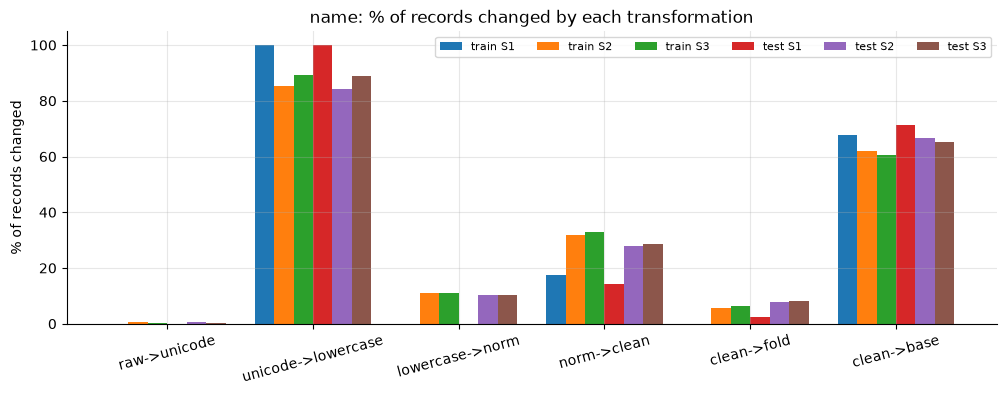

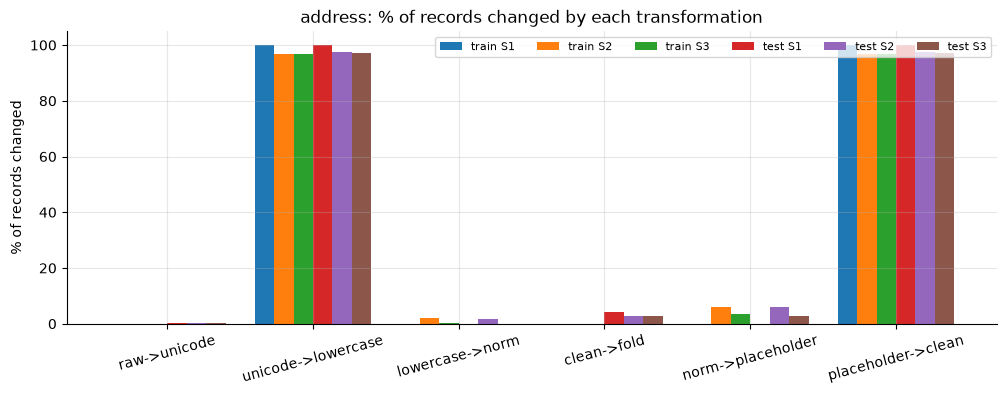

In [9]:
def plot_changes(df, field, fname):
    d = df.filter(pl.col("field") == field)
    cols = [c for c in d.columns if "->" in c and d[c].null_count() < d.height and "raw->clean" not in c]
    labels = [f"{a} {b}" for a, b in d.select("split", "source").iter_rows()]
    x = np.arange(len(cols)); w = 0.8 / len(labels)
    fig, ax = plt.subplots(figsize=(12, 3.8))
    for i, (lab, row) in enumerate(zip(labels, d.select(cols).iter_rows())):
        ax.bar(x + i * w, row, w, label=lab)
    ax.set_xticks(x + w * (len(labels) - 1) / 2, cols, rotation=15)
    ax.set(ylabel="% of records changed", title=f"{field}: % of records changed by each transformation")
    ax.legend(fontsize=8, ncol=6)
    save_fig(fig, fname)

plot_changes(chg_src, "name", "03_name_pct_changed")
plot_changes(chg_src, "address", "03_address_pct_changed")

**Interpretation.** How often each transformation fires, per record:

* **Lowercasing** touches 85–100 % of names and ~97–100 % of addresses. Case is pure formatting: S1 is always Title Case, S2 uses ALL CAPS in ~18 % of names and 52–66 % of addresses.
* **Unicode repair** is rare (0.03–0.6 %) but targeted: zero-width joiners in Indic names, and mojibake dashes/quotes in addresses.
* **Whitespace** fixes ~10–11 % of S2/S3 names but 0 % of S1 names. This is injected noise.
* **Punctuation** changes 14–17 % of S1 names and 28–33 % of S2/S3 names. It changes essentially every address, because commas are always present.
* **Placeholder-segment removal** changes 2.8–6.1 % of S2/S3 addresses. That is higher than the 2.9–3.6 % that literally contain `NULL`/`N/A`, because the same step also normalises spacing around commas and drops empty `,,` segments.
* The two **non-stored variants** fire on 0–8 % (accent fold) and 61–71 % (legal-form removal) of names.

## 4. Length and token statistics before vs after

In [10]:
def length_q(sp, s):
    lf = proc(sp, s)
    stats = {}
    for fld, raw, clean, ntok in (("name", "business_name_raw", "name_clean", "name_n_tokens"),
                                  ("address", "business_address_raw", "address_clean", "address_n_tokens")):
        rl, cl = pl.col(raw).str.len_chars(), pl.col(clean).str.len_chars()
        rt = pl.col(raw).str.count_matches(r"\S+")
        stats |= {f"{fld}_chars_raw_mean": rl.mean().round(2), f"{fld}_chars_clean_mean": cl.mean().round(2),
                  f"{fld}_chars_raw_p50": rl.median(), f"{fld}_chars_clean_p50": cl.median(),
                  f"{fld}_chars_raw_p95": rl.quantile(0.95), f"{fld}_chars_clean_p95": cl.quantile(0.95),
                  f"{fld}_tokens_raw_mean": rt.mean().round(3), f"{fld}_tokens_clean_mean": pl.col(ntok).mean().round(3),
                  f"{fld}_pct_more_tokens_after": pct(pl.col(ntok) > rt), f"{fld}_pct_fewer_tokens_after": pct(pl.col(ntok) < rt)}
    return lf.group_by("split", "source").agg(**stats)

lengths = save(order(per_file(length_q)), "04_length_token_stats")
lengths.transpose(include_header=True, header_name="metric",
                  column_names=[f"{a} {b}" for a, b in lengths.select("split", "source").iter_rows()]).slice(2)

metric,train S1,train S2,train S3,test S1,test S2,test S3
str,str,str,str,str,str,str
"""name_chars_raw_mean""","""24.03""","""25.1""","""25.2""","""23.84""","""25.7""","""25.66"""
"""name_chars_clean_mean""","""23.74""","""24.49""","""24.59""","""23.59""","""25.14""","""25.1"""
"""name_chars_raw_p50""","""24.0""","""25.0""","""25.0""","""24.0""","""25.0""","""25.0"""
"""name_chars_clean_p50""","""24.0""","""24.0""","""24.0""","""23.0""","""25.0""","""25.0"""
"""name_chars_raw_p95""","""37.0""","""40.0""","""42.0""","""36.0""","""42.0""","""42.0"""
"""name_chars_clean_p95""","""36.0""","""40.0""","""41.0""","""36.0""","""41.0""","""41.0"""
"""name_tokens_raw_mean""","""3.548""","""3.497""","""3.525""","""3.522""","""3.586""","""3.596"""
"""name_tokens_clean_mean""","""3.557""","""3.576""","""3.624""","""3.534""","""3.655""","""3.681"""
"""name_pct_more_tokens_after""","""1.002""","""9.394""","""10.614""","""1.025""","""8.025""","""9.078"""


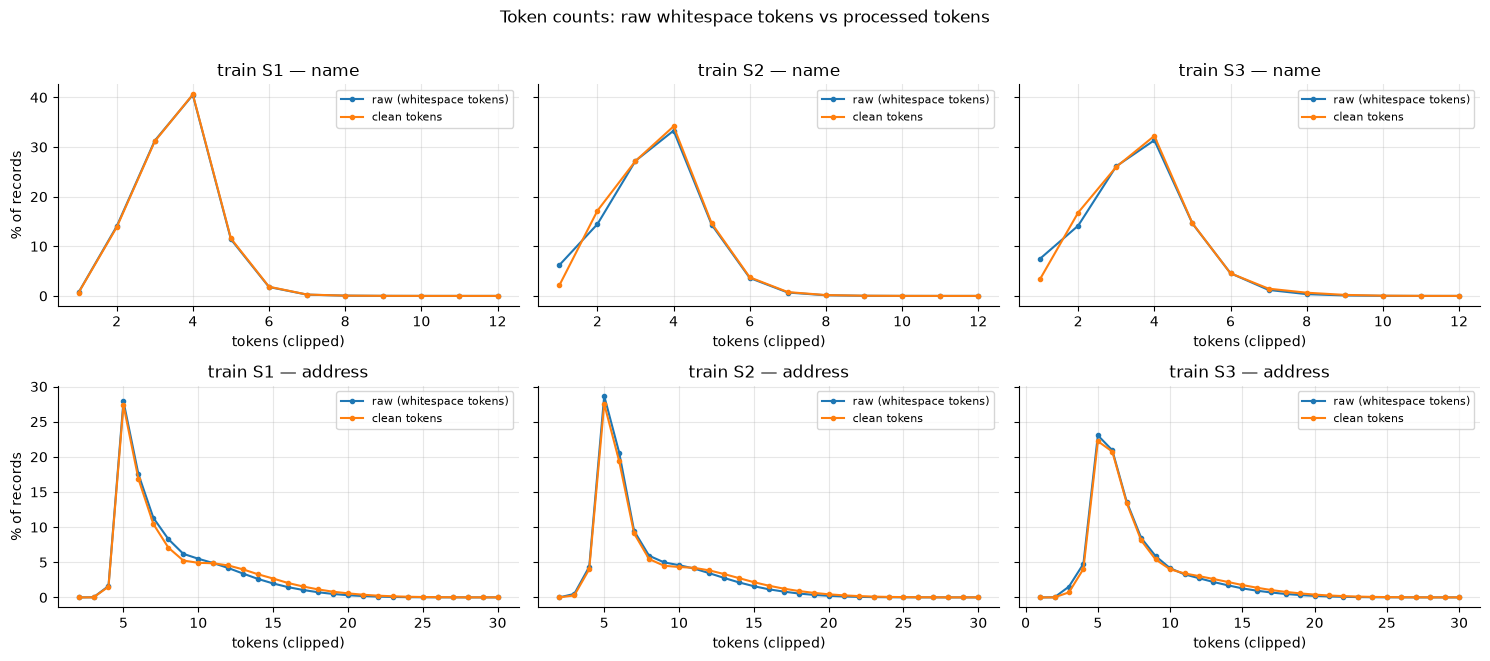

In [11]:
def hist_q(sp, s):
    lf = proc(sp, s)
    parts = []
    for fld, raw, clean, ntok, clip in (("name", "business_name_raw", "name_clean", "name_n_tokens", 12),
                                        ("address", "business_address_raw", "address_clean", "address_n_tokens", 30)):
        parts += [lf.select("split", "source", v=pl.col(raw).str.count_matches(r"\S+").cast(pl.Int64).clip(0, clip)).group_by("split", "source", "v").len()
                    .with_columns(field=pl.lit(fld), kind=pl.lit("raw (whitespace tokens)")),
                  lf.select("split", "source", v=pl.col(ntok).cast(pl.Int64).clip(0, clip)).group_by("split", "source", "v").len()
                    .with_columns(field=pl.lit(fld), kind=pl.lit("clean tokens"))]
    return pl.concat(parts)

tok_hist = save(per_file(hist_q, [f for f in FILES if f[0] == "train"]), "04_token_histograms_train")
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5), sharey="row")
for r, fld in enumerate(("name", "address")):
    for c, s in enumerate(C.SOURCES):
        ax = axes[r][c]
        for kind, d in tok_hist.filter((pl.col("field") == fld) & (pl.col("source") == s)).group_by("kind", maintain_order=True):
            d = d.sort("v")
            ax.plot(d["v"], d["len"] / d["len"].sum() * 100, marker=".", label=kind[0])
        ax.set(title=f"train {s} — {fld}", xlabel="tokens (clipped)")
        ax.legend(fontsize=8)
    axes[r][0].set_ylabel("% of records")
fig.suptitle("Token counts: raw whitespace tokens vs processed tokens", y=1.01)
fig.tight_layout()
save_fig(fig, "04_token_histograms")

**Interpretation.** Cleaning barely shortens names (−0.3 to −0.6 characters on average; medians unchanged). It shortens addresses by about 3.5 characters, mostly removed commas and placeholders. Token counts rise slightly, because punctuation becomes a token boundary:

* **Names:** 9–11 % of S2/S3 names gain tokens (`abc-123` → `abc 123`, `inc.,` splits) and 1.4–1.7 % lose tokens (junk such as `***`, `>>`, `--` removed). S1 is almost unaffected (1 % / 0.06 %).
* **Addresses:** 25–42 % gain tokens, because house numbers like `b/903`, `12/2` and `no.35` split into their parts.

The token-count distributions keep their shape. Cleaning does not truncate or explode any field.

## 5. Unique values and duplicates per representation (full data)

In [12]:
def dup_q(field, stages):
    def q(sp, s):
        lf = proc(sp, s)
        outs = []
        for st, e in stages.items():
            g = lf.select(k=e).drop_nulls().group_by("k").len("n")
            outs.append(g.select(split=pl.lit(sp), source=pl.lit(s), field=pl.lit(field), stage=pl.lit(st),
                                 non_null=pl.col("n").sum(), distinct=pl.len(),
                                 rows_in_duplicate_groups=pl.col("n").filter(pl.col("n") > 1).sum(),
                                 max_group=pl.col("n").max()))
        return pl.concat(outs)
    return q

name_keep = {k: NAME_STAGES[k] for k in ("raw", "norm", "clean", "fold", "base")}
addr_keep = {k: ADDR_STAGES[k] for k in ("raw", "norm", "clean", "fold")}
dups = pl.concat([per_file(dup_q("name", name_keep)), per_file(dup_q("address", addr_keep))])
dups = dups.with_columns(
    pct_rows_in_duplicates=(pl.col("rows_in_duplicate_groups") / pl.col("non_null") * 100).round(3),
    pct_distinct_vs_raw=(pl.col("distinct") / pl.col("distinct").first().over("split", "source", "field") * 100).round(3))
save(order(dups), "05_unique_and_duplicates")
dups.pivot(on="stage", index=["split", "source", "field"], values="pct_rows_in_duplicates").pipe(order)

split,source,field,raw,norm,clean,fold,base
str,str,str,f64,f64,f64,f64,f64
"""train""","""S1""","""address""",5.27,5.27,5.316,5.316,null
"""train""","""S1""","""name""",38.308,38.34,39.46,39.46,50.066
"""train""","""S2""","""address""",19.522,20.827,21.426,21.426,null
"""train""","""S2""","""name""",17.328,23.227,28.168,30.457,45.831
"""train""","""S3""","""address""",16.827,16.88,17.447,17.447,null
"""train""","""S3""","""name""",16.881,21.546,26.817,29.283,43.766
"""test""","""S1""","""address""",4.99,5.293,5.374,5.441,null
"""test""","""S1""","""name""",35.995,36.056,36.769,36.816,47.053
"""test""","""S2""","""address""",20.551,22.11,23.345,23.758,null


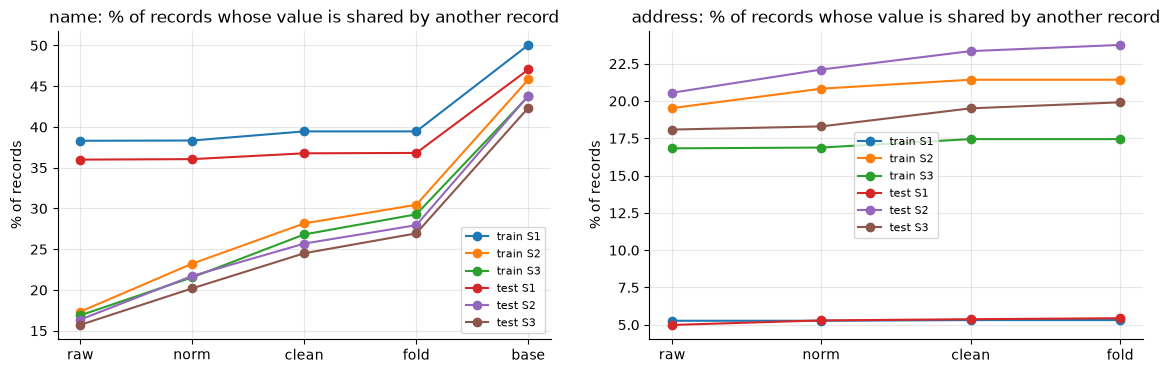

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, fld in zip(axes, ("name", "address")):
    d = dups.filter(pl.col("field") == fld)
    for (sp, s), g in d.group_by(["split", "source"], maintain_order=True):
        ax.plot(g["stage"], g["pct_rows_in_duplicates"], marker="o", label=f"{sp} {s}")
    ax.set(title=f"{fld}: % of records whose value is shared by another record", ylabel="% of records")
    ax.legend(fontsize=8)
save_fig(fig, "05_duplicates_by_stage")

**Interpretation.** Normalisation makes repeated values more common, as intended. In S2/S3 the share of names that share their exact value with another record rises from 16–17 % (raw) to 24–28 % (clean), 27–30 % (fold) and 42–46 % (base). In S1 it moves only 38.3 → 39.5 % (clean), because S1 was already consistently formatted. Legal-form removal is the big jump there (→ 50 %). Addresses change much less: S2 19.5 → 21.4 % and S1 5.3 → 5.3 %, because address variation is at the token level (abbreviations, order, missing parts) rather than in formatting. Most of the new sharing comes from spelling variants of the same business collapsing together. Section 6 checks whether any of it merges *different* businesses.

## 6. Collisions caused by normalisation

Normalising merges distinct raw strings. A merge is **benign** when both strings describe the same business, and
**harmful** when two different businesses become indistinguishable. Three pieces of evidence (all full data):

1. `normalization_effects.csv`: how many new collision keys each stage creates, per file. This is the pipeline's
   own measurement.
2. **S1 identity check.** S1 is de-duplicated on raw (name, address), so a processed (name, address) key shared by
   two S1 records is a merge of two reference entities.
3. **S2/S3 purity check (ground truth, validation only).** A processed key shared by S2/S3 records that belong to
   *different* S1 entities.

In [14]:
eff = existing("normalization_effects")
eff_tbl = (eff.filter(pl.col("stage") != "raw")
           .select("split", "source", "field", "stage", "pct_changed", "new_collision_keys", "rows_in_new_collisions",
                   "pct_unique_reduction_vs_raw"))
save(eff_tbl, "06_stage_collisions")
eff_tbl.filter(pl.col("split") == "train")

split,source,field,stage,pct_changed,new_collision_keys,rows_in_new_collisions,pct_unique_reduction_vs_raw
str,str,str,str,f64,i64,i64,f64
"""train""","""S1""","""address""","""unicode""",0.037,0,0,0.0
"""train""","""S1""","""address""","""lowercase""",100.0,0,0,0.0
"""train""","""S1""","""address""","""whitespace""",0.047,0,0,0.0
"""train""","""S1""","""address""","""placeholder""",0.001,0,0,0.0
"""train""","""S1""","""address""","""punctuation""",100.0,507,1042,0.024
"""train""","""S1""","""address""","""diacritic_fold""",0.001,0,0,0.024
"""train""","""S1""","""name""","""unicode""",0.0,0,0,0.0
"""train""","""S1""","""name""","""lowercase""",100.0,425,1714,0.028
"""train""","""S1""","""name""","""whitespace""",0.0,0,0,0.028


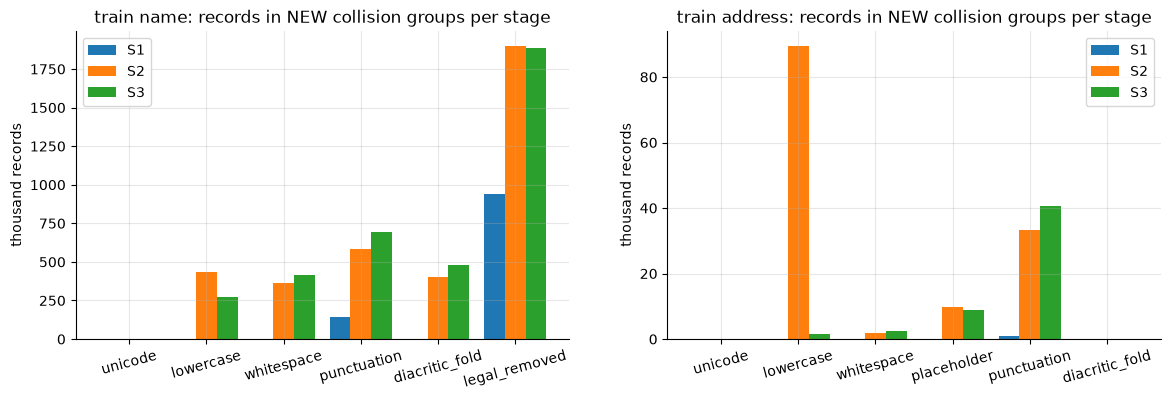

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, fld in zip(axes, ("name", "address")):
    d = eff_tbl.filter((pl.col("field") == fld) & (pl.col("split") == "train"))
    stages = d["stage"].unique(maintain_order=True).to_list()
    x = np.arange(len(stages)); w = 0.27
    for i, s in enumerate(C.SOURCES):
        dd = d.filter(pl.col("source") == s)
        vals = [dd.filter(pl.col("stage") == st)["rows_in_new_collisions"].sum() / 1e3 for st in stages]
        ax.bar(x + i * w, vals, w, label=s)
    ax.set_xticks(x + w, stages, rotation=15)
    ax.set(title=f"train {fld}: records in NEW collision groups per stage", ylabel="thousand records")
    ax.legend()
save_fig(fig, "06_stage_collisions")

In [16]:
s1_keys = existing("s1_key_collisions")
purity = existing("gt_s2s3_collision_purity")
harm = (s1_keys.filter(pl.col("key").str.contains(r"\+"))
        .select("split", "key", s1_records="records", s1_entities_merged="records_in_collisions", s1_merge_groups="colliding_keys")
        .pivot(on="split", index="key", values=["s1_entities_merged", "s1_merge_groups"])
        .join(purity.select("key", s2s3_groups_mixing_entities="mixed_entity_groups",
                            s2s3_records_in_mixed_groups="records_in_mixed_groups", s2s3_groups_gt1="groups_size_gt1"),
              on="key", how="left"))
save(harm, "06_harmful_collisions_name_address_keys")
harm

key,s1_entities_merged_train,s1_entities_merged_test,s1_merge_groups_train,s1_merge_groups_test,s2s3_groups_mixing_entities,s2s3_records_in_mixed_groups,s2s3_groups_gt1
str,i64,i64,i64,i64,i64,i64,i64
"""name_raw + address_raw""",0,0,0,0,0,0,43037
"""name_norm + address_norm""",0,0,0,0,0,0,77601
"""name_clean + address_clean""",0,2,0,1,1,2,114605
"""folded name_clean + folded address_clean""",0,2,0,1,1,2,136899
"""name_base + address_clean""",8,61,4,30,7,14,251994
"""sorted name_tokens + sorted address_tokens""",0,6,0,3,1,2,201854


In [17]:
name_only = (s1_keys.filter(~pl.col("key").str.contains(r"\+"))
             .select("split", "key", "pct_records_in_collisions", "max_group")
             .pivot(on="split", index="key", values=["pct_records_in_collisions", "max_group"])
             .join(purity.select("key", "pct_records_in_mixed_groups"), on="key", how="left"))
save(name_only, "06_single_field_key_ambiguity")
name_only

key,pct_records_in_collisions_train,pct_records_in_collisions_test,max_group_train,max_group_test,pct_records_in_mixed_groups
str,f64,f64,i64,i64,f64
"""name_raw only""",38.3078,35.9952,253,205,15.466
"""name_clean only""",39.4598,36.7693,253,205,22.279
"""name_base only""",50.0661,47.0534,575,516,32.246
"""address_clean only""",5.3155,5.3739,14,101,null


In [18]:
existing("s1_key_collision_examples").select("split", "key", "entity_id", "business_name_raw", "business_address_raw")

split,key,entity_id,business_name_raw,business_address_raw
str,str,str,str,str
"""train""","""name_base + address_clean""","""S1-778720701""","""Bobinette Becerril All Physical LP""","""2920 Max Loop, Badger, AK"""
"""train""","""name_base + address_clean""","""S1-668405556""","""Bobinette Becerril All Physical LLC""","""2920 Max Loop, Badger, AK"""
"""train""","""name_base + address_clean""","""S1-813427750""","""Colburn, Shannon & Buzzard""","""3905 Kleitz Road, Evansville, IN"""
"""train""","""name_base + address_clean""","""S1-640479829""","""Colburn, Shannon & Buzzard Inc""","""3905 Kleitz Road, Evansville, IN"""
"""train""","""name_base + address_clean""","""S1-984803837""","""FKO Agents Limited""","""Khasra No. 175, 170, 90/2, 176, Pipliya Dhakad, Huzur, Bhopal, Madhya Pradesh"""
"""train""","""name_base + address_clean""","""S1-598232727""","""FKO Agents Corp""","""Khasra No. 175, 170, 90/2, 176, Pipliya Dhakad, Huzur, Bhopal, Madhya Pradesh"""
"""train""","""name_base + address_clean""","""S1-256915606""","""Lloyd and Poore P.C.""","""498 Olde Mill Drive, Westerville, OH"""
"""train""","""name_base + address_clean""","""S1-96188450""","""Lloyd and Poore LP""","""498 Olde Mill Drive, Westerville, OH"""
"""test""","""name_clean + address_clean""","""S1-202327133""","""Lille Club SAS""","""72-74 RUE Royale, Maison des associations, Lille, Hauts-de-France"""


**Interpretation.** Stage-level collisions are large for names. For train S2, lowercase merges 432 k records, whitespace 366 k, punctuation 587 k, fold 404 k and legal removal 1.9 M into newly shared keys. For addresses they are small (≤ 90 k). Most of these are benign; the question is which ones merge **different entities**:

* **Name + address keys are essentially collision-free.** S1 is de-duplicated on raw (name, address) and stays unique under `norm` in both splits and under `clean`/`fold` in train. In test, `clean` merges exactly 1 pair: two `Lille Club SAS` records at `72-74 RUE Royale` vs `72 -74 RUE Royale`, which is a near-duplicate *inside* S1 rather than a harmful merge. In S2/S3, `clean` creates 1 mixed-entity group of 2 records out of 114,605 shared keys.
* **Legal-form removal is the only lossy step with measurable harm.** `name_base + address_clean` merges **4 S1 pairs in train and 30 in test**, and creates 7 mixed groups (14 records) in S2/S3. The examples are genuinely different businesses at one address that differ *only* in legal form: `Lille Sante SARL` vs `Lille Sante SCI`, `Orthopedic Center LLC` vs `… Inc`, `FKO Agents Limited` vs `… Corp`.
* **Name-only keys are ambiguous by nature.** Even raw names put 38 % of S1 records in shared groups, and 15.5 % of S2/S3 records sit in groups that span several entities. `clean` raises this to 22.3 % and `base` to 32.2 %. Normalising names increases name-only ambiguity; it does not create it.

## 7. Country-wise effects (includes France, test only)

In [19]:
chg_cty = order(pl.concat([per_file(changed_q("name", NAME_STAGES, NAME_STEPS, ("country_clean",))),
                           per_file(changed_q("address", ADDR_STAGES, ADDR_STEPS, ("country_clean",)))], how="diagonal")
                .rename({"country_clean": "country"}))
save(chg_cty, "07_pct_changed_by_country")
chg_cty.filter(pl.col("field") == "name").select("split", "source", "country", "records", "raw->unicode", "unicode->lowercase",
                                                 "lowercase->norm", "norm->clean", "clean->fold", "clean->base")

split,source,country,records,raw->unicode,unicode->lowercase,lowercase->norm,norm->clean,clean->fold,clean->base
str,str,str,u32,f64,f64,f64,f64,f64,f64
"""train""","""S1""","""India""",883188,0.0,100.0,0.0,8.233,0.0,84.291
"""train""","""S1""","""US""",1323633,0.0,100.0,0.0,23.658,0.0,56.927
"""train""","""S2""","""India""",2017799,1.271,73.049,10.037,24.369,4.366,78.857
"""train""","""S2""","""US""",3016817,0.0,93.312,11.663,36.875,6.701,50.908
"""train""","""S3""","""India""",2115547,0.686,83.265,10.536,25.842,5.325,76.251
"""train""","""S3""","""US""",3170056,0.0,93.053,11.127,37.661,6.8,50.084
"""test""","""S1""","""France""",259452,0.001,100.0,0.0,10.321,15.721,67.311
"""test""","""S1""","""India""",809986,0.0,100.0,0.0,8.19,0.0,84.257
"""test""","""S1""","""US""",663106,0.0,100.0,0.0,23.577,0.0,56.868


In [20]:
chg_cty.filter(pl.col("field") == "address").select("split", "source", "country", "records", "raw->unicode", "lowercase->norm",
                                                    "norm->placeholder", "placeholder->clean", "clean->fold")

split,source,country,records,raw->unicode,lowercase->norm,norm->placeholder,placeholder->clean,clean->fold
str,str,str,u32,f64,f64,f64,f64,f64
"""train""","""S1""","""India""",883188,0.091,0.008,0.004,100.0,0.003
"""train""","""S1""","""US""",1323633,0.001,0.073,0.0,100.0,0.0
"""train""","""S2""","""India""",2017799,0.081,1.226,9.409,97.133,0.003
"""train""","""S2""","""US""",3016817,0.0,2.75,3.857,96.317,0.002
"""train""","""S3""","""India""",2115547,0.068,0.006,2.787,96.93,0.002
"""train""","""S3""","""US""",3170056,0.0,0.154,3.675,96.499,0.002
"""test""","""S1""","""France""",259452,0.806,0.108,0.014,100.0,27.831
"""test""","""S1""","""India""",809986,0.09,0.008,0.004,100.0,0.002
"""test""","""S1""","""US""",663106,0.0,0.071,0.0,100.0,0.0


In [21]:
def uniq_country_q(sp, s):
    lf = proc(sp, s)
    return lf.group_by("split", "source", country="country_clean").agg(
        records=pl.len(),
        **{f"name_{k}": e.n_unique() for k, e in name_keep.items()},
        **{f"addr_{k}": e.drop_nulls().n_unique() for k, e in addr_keep.items()})

uc = order(per_file(uniq_country_q))
uc = uc.with_columns(
    name_pct_distinct_lost_clean=((1 - pl.col("name_clean") / pl.col("name_raw")) * 100).round(3),
    name_pct_distinct_lost_fold_extra=((1 - pl.col("name_fold") / pl.col("name_clean")) * 100).round(3),
    name_pct_distinct_lost_base_extra=((1 - pl.col("name_base") / pl.col("name_clean")) * 100).round(3),
    addr_pct_distinct_lost_clean=((1 - pl.col("addr_clean") / pl.col("addr_raw")) * 100).round(3),
    addr_pct_distinct_lost_fold_extra=((1 - pl.col("addr_fold") / pl.col("addr_clean")) * 100).round(3))
save(uc, "07_uniqueness_by_country")
uc.select("split", "source", "country", "records", *[c for c in uc.columns if "pct_distinct_lost" in c])

split,source,country,records,name_pct_distinct_lost_clean,name_pct_distinct_lost_fold_extra,name_pct_distinct_lost_base_extra,addr_pct_distinct_lost_clean,addr_pct_distinct_lost_fold_extra
str,str,str,u32,f64,f64,f64,f64,f64
"""train""","""S1""","""India""",883188,0.448,0.0,14.086,0.059,0.0
"""train""","""S1""","""US""",1323633,1.961,0.0,13.397,0.0,0.0
"""train""","""S2""","""India""",2017799,5.747,1.282,19.388,0.741,0.0
"""train""","""S2""","""US""",3016817,10.592,2.454,16.681,1.616,0.0
"""train""","""S3""","""India""",2115547,6.405,1.754,19.115,0.818,0.0
"""train""","""S3""","""US""",3170056,9.212,2.443,15.317,0.168,0.0
"""test""","""S1""","""France""",259452,0.135,0.353,15.432,1.331,0.263
"""test""","""S1""","""India""",809986,0.412,0.0,13.944,0.056,0.0
"""test""","""S1""","""US""",663106,1.676,0.0,10.713,0.0,0.0


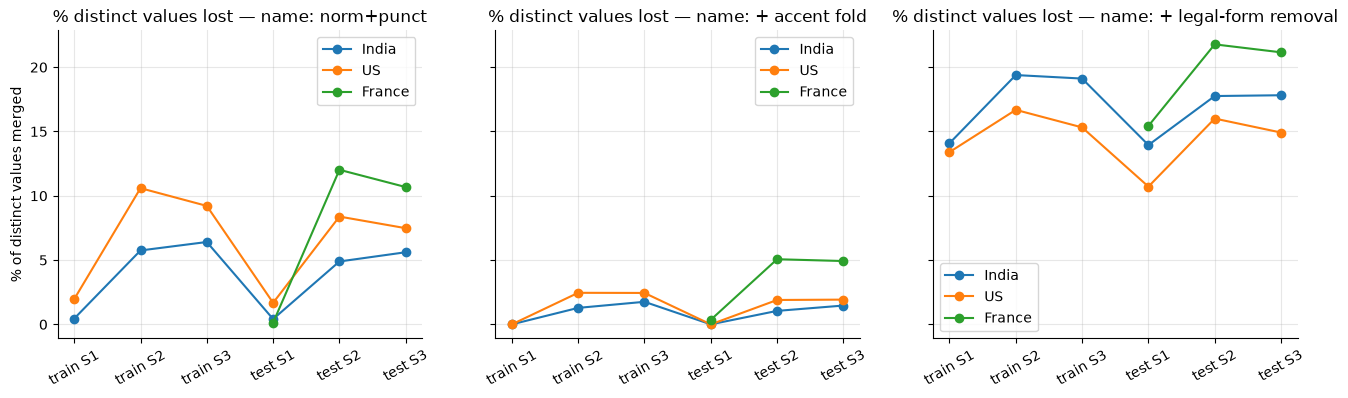

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
metrics = [("name_pct_distinct_lost_clean", "name: norm+punct"), ("name_pct_distinct_lost_fold_extra", "name: + accent fold"),
           ("name_pct_distinct_lost_base_extra", "name: + legal-form removal")]
for ax, (m, title) in zip(axes, metrics):
    d = uc.with_columns(lbl=pl.col("split") + " " + pl.col("source"))
    for ctry, g in d.group_by("country", maintain_order=True):
        ax.plot(g["lbl"], g[m], marker="o", label=ctry[0])
    ax.set(title=f"% distinct values lost — {title}", xlabel="")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
axes[0].set_ylabel("% of distinct values merged")
save_fig(fig, "07_uniqueness_loss_by_country")

**Interpretation.**

* **US:** punctuation matters most (`norm→clean` changes 36–38 % of S2/S3 names, e.g. `Inc.`, `, LLC`, `L.L.C.`), and normalisation merges 7.5–10.6 % of distinct S2/S3 names.
* **India:** unicode repair is only active here (1.3 % of S2 names: zero-width joiners in Indic scripts). Only 73–84 % of names change case, because non-Latin names have no case. Placeholder segments are 2.5× more frequent in S2 addresses (9.4 % vs 3.9 % US). Legal-form removal changes 76–84 % of names (Private/Limited everywhere).
* **France (test only)** behaves differently for accents. Folding changes **15.7 % of S1 names and 27.8 % of S1 addresses**, where the accents are genuine French spelling, and 24 % of S2/S3 names. It merges 5 % of distinct S2/S3 French names but only 0.35 % in S1. In train (US/India) accents are injected noise, and folding merges 1–2.5 %. France also has the highest punctuation/case merge rate within test S2/S3 (10.7–12 % of distinct names vs 7.5–8.4 % US).

Folding therefore means "remove noise" for US/India but "remove real spelling" for France. There are no French labels to show which effect dominates.

## 8. Ground-truth-aware impact (train, validation only)

For a deterministic **10 % hash sample of S1 entities** with all their true S2/S3 matches, the question is: how
often is a representation **exactly equal** on both sides of a true pair? Equality is not a matching rule. It
measures how much superficial variation each transformation removes between records that are known to be the same
business. The ground truth defines no preprocessing rule here.

The table also counts **lost agreements**: pairs that were equal at one stage but differ at the next. Every stage is
a deterministic function, so this must be 0. It is shown as a check that no step destroys agreement that already
existed.

In [23]:
PCT = 10
pairs = collect(pl.scan_parquet(C.GT_PROCESSED).select(s1_id="source1_entity_id", m_id="matched_entity_ids")
                .filter(pl.col("s1_id").hash(SEED) % 100 < PCT).explode("m_id").drop_nulls("m_id"))
need = ["entity_id", "business_name_raw", "business_address_raw", "name_norm", "name_clean", "name_base", "name_tokens",
        "address_norm", "address_clean", "address_tokens", "address_numbers", "postal_code_candidate", "country_clean", "source"]

def side(lf, ids, prefix):
    lf = lf.select(need).join(ids.lazy(), on="entity_id", how="semi")
    return collect(lf.select([pl.col(c).alias(f"{prefix}{c}") for c in need]))

a = side(proc("train", "S1"), pairs.select(entity_id="s1_id").unique(), "a_")
b = pl.concat([side(proc("train", s), pairs.select(entity_id="m_id"), "b_") for s in ("S2", "S3")])
pp = pairs.join(a, left_on="s1_id", right_on="a_entity_id").join(b, left_on="m_id", right_on="b_entity_id")
print(f"{pp.height:,} true pairs from {pp['s1_id'].n_unique():,} S1 entities ({PCT}% sample)")

764,210 true pairs from 208,131 S1 entities (10% sample)


In [24]:
def both(stage_expr_fn):
    '''Apply the same pipeline expression to the S1 side (a_) and the match side (b_).'''
    return stage_expr_fn("a_"), stage_expr_fn("b_")

rep = {
    # names
    "name: raw":       both(lambda p: pl.col(f"{p}business_name_raw")),
    "name: unicode":   both(lambda p: T.unicode_stage(f"{p}business_name_raw")),
    "name: lowercase": both(lambda p: T.lowercase_stage(T.unicode_stage(f"{p}business_name_raw"))),
    "name: norm":      both(lambda p: pl.col(f"{p}name_norm")),
    "name: clean":     both(lambda p: pl.col(f"{p}name_clean")),
    "name: fold":      both(lambda p: T.fold_diacritics(f"{p}name_clean")),
    "name: base":      both(lambda p: pl.col(f"{p}name_base")),
    "name: base+fold": both(lambda p: T.fold_diacritics(f"{p}name_base")),
    # addresses
    "address: raw":         both(lambda p: pl.col(f"{p}business_address_raw")),
    "address: unicode":     both(lambda p: T.unicode_stage(f"{p}business_address_raw")),
    "address: lowercase":   both(lambda p: T.lowercase_stage(T.unicode_stage(f"{p}business_address_raw"))),
    "address: norm":        both(lambda p: pl.col(f"{p}address_norm")),
    "address: placeholder": both(lambda p: T.address_placeholder_stage(f"{p}address_norm")),
    "address: clean":       both(lambda p: pl.col(f"{p}address_clean")),
    "address: fold":        both(lambda p: T.fold_diacritics(f"{p}address_clean")),
    # structured parts (sets, order ignored)
    "numbers as written (set)":   both(lambda p: T.numbers(f"{p}address_norm").list.unique().list.sort()),
    "numbers zero-stripped (set)": both(lambda p: pl.col(f"{p}address_numbers").list.unique().list.sort()),
}
eq = {k: (x == y).fill_null(False) & x.is_not_null() & y.is_not_null()
      if not k.startswith("numbers") else (x == y).fill_null(False) & (x.list.len() > 0)
      for k, (x, y) in rep.items()}
flags = pp.select("a_country_clean", "b_source", **eq)
agree = (flags.group_by(country="a_country_clean", match_source="b_source")
         .agg(pairs=pl.len(), **{k: pct(pl.col(k)) for k in eq}).sort("country", "match_source"))
agree_long = agree.unpivot(index=["country", "match_source", "pairs"], variable_name="representation", value_name="pct_exactly_equal")
save(agree_long, "08_gt_pair_exact_agreement")
agree_wide = agree_long.with_columns(col=pl.format("{} S1-{}", "country", "match_source")).pivot(
    on="col", index="representation", values="pct_exactly_equal")
agree_wide

representation,India S1-S2,India S1-S3,US S1-S2,US S1-S3
str,f64,f64,f64,f64
"""name: raw""",2.667,2.682,6.172,5.784
"""name: unicode""",2.667,2.682,6.172,5.784
"""name: lowercase""",6.325,6.563,14.166,13.065
"""name: norm""",10.195,11.377,19.275,18.791
"""name: clean""",14.997,16.986,27.277,26.888
"""name: fold""",17.507,20.158,31.956,31.575
"""name: base""",40.854,42.324,50.44,46.137
"""name: base+fold""",43.11,45.015,55.51,51.146
"""address: raw""",0.0,4.078,0.0,4.38


In [25]:
STEPS_GT = ([(f"name: {a}", f"name: {b}") for a, b in NAME_STEPS] + [("name: base", "name: base+fold")] +
            [(f"address: {a}", f"address: {b}") for a, b in ADDR_STEPS] +
            [("numbers as written (set)", "numbers zero-stripped (set)")])
chain = pl.DataFrame([{"from": a_, "to": b_,
                       "pairs_equal_before": int(flags[a_].sum()), "pairs_equal_after": int(flags[b_].sum()),
                       "gained": int((~flags[a_] & flags[b_]).sum()), "lost": int((flags[a_] & ~flags[b_]).sum())}
                      for a_, b_ in STEPS_GT]).with_columns(
    gain_pct_of_pairs=(pl.col("gained") / flags.height * 100).round(3))
save(chain, "08_gt_stage_gain_loss")
chain

from,to,pairs_equal_before,pairs_equal_after,gained,lost,gain_pct_of_pairs
str,str,i64,i64,i64,i64,f64
"""name: raw""","""name: unicode""",35540,35540,0,0,0.0
"""name: unicode""","""name: lowercase""",35540,82018,46478,0,6.082
"""name: lowercase""","""name: norm""",82018,120221,38203,0,4.999
"""name: norm""","""name: clean""",120221,173073,52852,0,6.916
"""name: clean""","""name: fold""",173073,203256,30183,0,3.95
"""name: clean""","""name: base""",173073,348261,175190,2,22.924
"""name: base""","""name: base+fold""",348261,378932,30671,0,4.013
"""address: raw""","""address: unicode""",16807,16807,0,0,0.0
"""address: unicode""","""address: lowercase""",16807,55274,38467,0,5.034


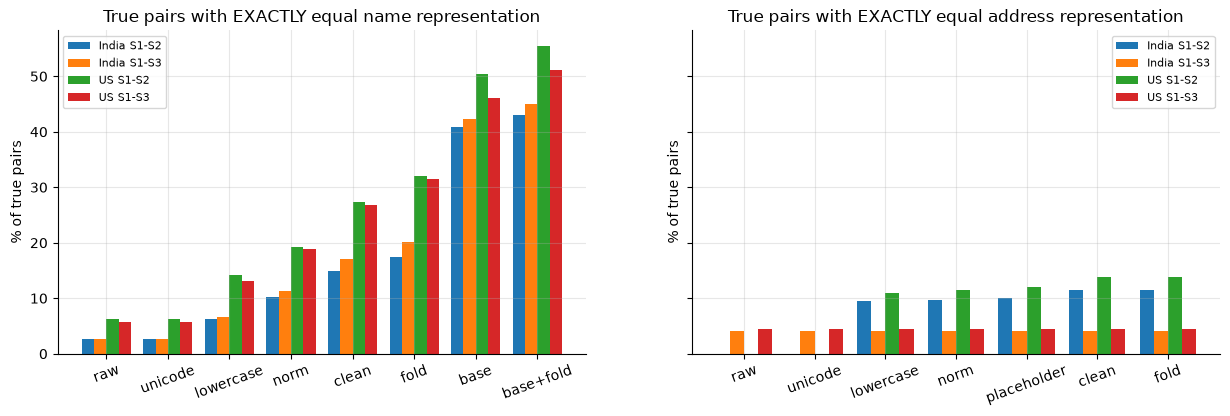

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
for ax, prefix in zip(axes, ("name", "address")):
    d = agree_long.filter(pl.col("representation").str.starts_with(prefix + ":"))
    reps = d["representation"].unique(maintain_order=True).to_list()
    grp = d.select("country", "match_source").unique(maintain_order=True).rows()
    x = np.arange(len(reps)); w = 0.8 / len(grp)
    for i, (ctry, src) in enumerate(grp):
        dd = d.filter((pl.col("country") == ctry) & (pl.col("match_source") == src))
        ax.bar(x + i * w, dd["pct_exactly_equal"], w, label=f"{ctry} S1-{src}")
    ax.set_xticks(x + w * (len(grp) - 1) / 2, [r.split(": ")[1] for r in reps], rotation=20)
    ax.set(title=f"True pairs with EXACTLY equal {prefix} representation", ylabel="% of true pairs")
    ax.legend(fontsize=8)
save_fig(fig, "08_gt_pair_exact_agreement")

In [27]:
# Pairs that stay different even after all normalisation: what is left? (real examples)
residual = (pp.filter(~eq["name: base+fold"])
            .with_columns(h=pl.col("m_id").hash(SEED)).sort("h")
            .group_by("a_country_clean", maintain_order=True).head(5)
            .select(country="a_country_clean", s1_name_clean="a_name_clean", match_name_raw="b_business_name_raw",
                    match_name_clean="b_name_clean"))
save(residual, "08_gt_residual_name_differences")
residual

country,s1_name_clean,match_name_raw,match_name_clean
str,str,str,str
"""US""","""physical therapy valley care associates group""","""PHYSICALTHERAPYVALLEY.COM""","""physicaltherapyvalley com"""
"""US""","""atlantic united pizza""","""At1antic United Pizza""","""at1antic united pizza"""
"""US""","""ur metropolitan property llc""","""UR METROPOLITAN PROPERTY LLC - 3027787816""","""ur metropolitan property llc 3027787816"""
"""US""","""hiett sherill do md pc""","""Hiett, Sherill, D.0., M.D., P.C.""","""hiett sherill d 0 md pc"""
"""US""","""martins patriot jewelers inc""","""Martin's Patriot Inc Center""","""martins patriot inc center"""
"""India""","""alpha media limited""","""अल्फा मीडिया लिमिटेड""","""अल्फा मीडिया लिमिटेड"""
"""India""","""dza ventures private limited""","""DZA Venutsre Private Limited""","""dza venutsre private limited"""
"""India""","""excellent & co""","""Exelleht & Co""","""exelleht & co"""
"""India""","""ramling & co""","""M/s Ramling & Co""","""m s ramling & co"""


**Interpretation.** The table measures the share of true S1→S2/S3 pairs that are exactly equal (10 % sample: 764,210 pairs, 208,131 S1 entities):

* **No stage destroys existing agreement.** `lost` = 0 at every step. The only exception is 2 pairs at legal-form removal, where both names are *only* legal forms (`SA`, `PC`) and therefore become null.
* **Names.** Exact agreement grows from 2.7 % (India) / 5.8–6.2 % (US) raw to **15–17 % / 27 % with the stored `clean`** and 17.5–20 % / 32 % with fold. Legal-form removal lifts it to 41–50 %, and base + fold to 43–56 %. Per-step gains, as % of all pairs: lowercase +6.1, whitespace +5.0, punctuation +6.9, fold +4.0, legal removal +22.9, fold on base +4.0. Unicode repair gives +0.0 exact-equality gain; it fixes invisible characters that other differences usually mask.
* **Addresses.** Normalisation helps S2 (upper-case, reformatted): 0 % → 11.5–13.9 %. It does not help S3 at all (4.1–4.4 % before and after), because S3 changes state names, component order and abbreviations rather than formatting. Whole-address equality is therefore a weak signal whatever the normalisation.
* **Address numbers** agree far more often than address strings: the digit set is identical for 57–66 % of pairs as written and **59–70 % after stripping leading zeros**. Zero-stripping gains 3.3 % of pairs and loses none.
* **What stays different** after all normalisation: domain-style concatenations (`PHYSICALTHERAPYVALLEY.COM`), digit-for-letter typos (`At1antic`, `D.0.`), appended phone numbers, letter typos (`Venutsre`, `Exelleht`), token substitutions (`Patriot Inc Center`), honorifics (`M/s`) and transliterated Indic names. These are fuzzy-matching problems, not preprocessing problems.

## 9. Representative transformation examples (real records)

In [28]:
CASES = {
    "mojibake repaired":          pl.col("business_address_raw").str.contains(r"[âÂ]\x{80}"),
    "zero-width char removed":    pl.col("business_name_raw").str.contains(r"\p{Cf}"),
    "dotted acronym joined":      pl.col("business_name_raw").str.contains(r"\b\p{L}\.\p{L}\."),
    "apostrophe joined":          pl.col("business_name_raw").str.contains(r"\p{L}'\p{L}"),
    "leading junk / brackets":    pl.col("name_has_leading_junk") | pl.col("name_has_brackets"),
    "repeated whitespace":        pl.col("name_has_repeated_whitespace"),
    "domain-only name":           pl.col("name_is_domain_only"),
    "legal form first":           pl.col("name_legal_at_start"),
    "Indic legal form":           pl.col("name_has_non_latin") & pl.col("name_has_legal_form"),
    "placeholder segment":        pl.col("address_has_placeholder"),
    "French accents":             (pl.col("country_clean") == "France") & pl.col("name_has_latin_diacritics")
                                  & pl.col("address_has_latin_diacritics"),
}
ex_cols = ["entity_id", "country_clean", "business_name_raw", "name_clean", "name_base", "name_legal_forms",
           "business_address_raw", "address_clean", "address_numbers"]
examples = []
for case, cond in CASES.items():
    for sp, s in (("train", "S2"), ("train", "S3"), ("test", "S2")):
        d = collect(proc(sp, s).filter(cond & (pl.col("entity_id").hash(SEED) % 97 == 0)).select(ex_cols).head(1))
        examples.append(d.with_columns(case=pl.lit(case), file=pl.lit(f"{sp} {s}"),
                                       name_legal_forms=pl.col("name_legal_forms").list.join(","),
                                       address_numbers=pl.col("address_numbers").list.join(",")))
examples = pl.concat(examples).unique(["case", "entity_id"], maintain_order=True).group_by("case", maintain_order=True).head(2)
save(examples.select("case", "file", *ex_cols), "09_transformation_examples")
examples.select("case", "business_name_raw", "name_clean", "name_base", "name_legal_forms")

case,business_name_raw,name_clean,name_base,name_legal_forms
str,str,str,str,str
"""mojibake repaired""","""आनंद आईटी प्राइवेट लिमिटेड""","""आनंद आईटी प्राइवेट लिमिटेड""","""आनंद आईटी""","""pvt,ltd"""
"""mojibake repaired""","""North Finance Public Limited""","""north finance public limited""","""north finance public""","""ltd"""
"""zero-width char removed""","""ಪರ್ಫೆಕ್ಟ್ ಕನ್‌ಸ್ಟ್ರಕ್ಷನ್ಸ್ ಲಿಮಿಟೆಡ್""","""ಪರ್ಫೆಕ್ಟ್ ಕನ್ಸ್ಟ್ರಕ್ಷನ್ಸ್ ಲಿಮಿಟೆಡ್""","""ಪರ್ಫೆಕ್ಟ್ ಕನ್ಸ್ಟ್ರಕ್ಷನ್ಸ್""","""ltd"""
"""zero-width char removed""","""బ్రైట్ కన్‌స్ట్రక్షన్ ఎల్‌ఎల్‌పీ""","""బ్రైట్ కన్స్ట్రక్షన్ ఎల్ఎల్పీ""","""బ్రైట్ కన్స్ట్రక్షన్ ఎల్ఎల్పీ""",""""""
"""dotted acronym joined""","""Kolk Secure Starlink L.L.C.""","""kolk secure starlink llc""","""kolk secure starlink""","""llc"""
"""dotted acronym joined""","""Pacific L.L.C. Services""","""pacific llc services""","""pacific services""","""llc"""
"""apostrophe joined""","""SERVICES AMELITA'S PIEDMONT LLC""","""services amelitas piedmont llc""","""services amelitas piedmont""","""llc"""
"""apostrophe joined""","""Estell's Creative""","""estells creative""","""estells creative""",""""""
"""leading junk / brackets""","""Jupiter Consulting (India) Private - 9635314554""","""jupiter consulting india private 9635314554""","""jupiter consulting india 9635314554""","""pvt"""


In [29]:
examples.filter(pl.col("case").is_in(["mojibake repaired", "placeholder segment", "French accents"])) \
        .select("case", "business_address_raw", "address_clean", "address_numbers")

case,business_address_raw,address_clean,address_numbers
str,str,str,str
"""mojibake repaired""","""LV TNWER SA Â 94, D.D. PURAM, BAREILLY, Uttar Pradesh""","""lv tnwer sa 94 dd puram bareilly uttar pradesh""","""94"""
"""mojibake repaired""","""#640 Unit No.1530, 15Th Floor, Wingâ B, One Bkc, Plot No. C-66, G Block, Bandra Kurla Co…","""640 unit no 1530 15th floor wing b one bkc plot no c 66 g block bandra kurla com plex mumb…","""640,1530,15,66"""
"""placeholder segment""","""51/150-38-10 NGO COLONY, RAYACHOTI, N/A, ఆంధ్రప్రదేశ్""","""51 150 38 10 ngo colony rayachoti ఆంధ్రప్రదేశ్""","""51,150,38,10"""
"""placeholder segment""","""Sec Kondivita Co Op Housing Society Ltd Building No 2 Flat No 24 Road, <NULL>, Mumbai, Mum…","""sec kondivita co op housing society ltd building no 2 flat no 24 road mumbai mumbai city m…","""2,24"""
"""French accents""","""NO 3 ALL. HENRI MATISSE, MÉRIGNAC""","""no 3 all henri matisse mérignac""","""3"""


**Interpretation.** The real records show each rule doing exactly one thing:

* `L.L.C.` → `llc`, `AMELITA'S` → `amelitas`, `Jupiter Consulting (India) Private - 9635314554` → `jupiter consulting india private 9635314554`: digits are kept.
* Zero-width joiners are removed inside Kannada/Telugu words without touching vowel signs.
* `प्रा. लि.` is recognised as `pvt,ltd`.
* `LLC Liberty Cgpoley` → base `liberty cgpoley`.
* Placeholder segments (`N/A`, `<NULL>`) are dropped from addresses while house numbers stay.
* Mojibake `Â` + C1 bytes becomes a separator (`SA Â 94` → `sa 94`).
* French accents stay in every stored column (`comité des vallons`); only the on-demand fold removes them.

## 10. Potentially harmful information loss

Every place where a processed representation carries **less information** than the raw value is audited below.
Each item gives how often it happens, whether the information is still available in a stored column, and evidence
on whether it matters.

In [30]:
SYMBOLS = {"+": r"\+", "@": "@", "#": "#", "%": "%", "$": r"\$", "/": "/", "&": "&"}
def sym_q(sp, s):
    return proc(sp, s).group_by("split", "source").agg(
        records=pl.len(),
        **{f"name '{k}'": pct(pl.col("name_norm").str.contains(p)) for k, p in SYMBOLS.items()},
        **{f"addr '{k}'": pct(pl.col("address_norm").str.contains(p)) for k, p in SYMBOLS.items() if k in "#/&"},
        **{"addr slash-number (11/74, 1/2)": pct(pl.col("address_norm").str.contains(r"\b\d+/\d+\b"))})
symbols = save(order(per_file(sym_q)), "10_symbols_dropped_by_punctuation_stage")
symbols

split,source,records,name '+',name '@',name '#',name '%',name '$',name '/',name '&',addr '#',addr '/',addr '&',"addr slash-number (11/74, 1/2)"
str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""train""","""S1""",2206821,0.157,0.023,0.064,0.0,0.0,0.235,5.071,0.754,13.744,0.88,7.542
"""train""","""S2""",5034616,0.512,0.336,0.678,0.0,0.0,0.728,4.153,7.582,16.029,0.808,8.661
"""train""","""S3""",5285603,0.618,0.332,0.678,0.0,0.0,1.651,4.104,10.274,15.323,0.693,8.256
"""test""","""S1""",1732544,0.102,0.014,0.039,0.0,0.0,0.154,5.017,0.766,16.026,1.037,8.762
"""test""","""S2""",4887273,0.451,0.257,0.52,0.0,0.0,0.744,4.268,8.014,18.11,0.961,9.648
"""test""","""S3""",5082316,0.538,0.262,0.528,0.0,0.0,1.459,4.194,9.663,17.33,0.842,9.184


In [31]:
# Punctuation-only collisions in S1 (the de-duplicated reference): distinct name_norm values merged by the punctuation stage
def punct_merge(sp):
    g = collect(proc(sp, "S1").group_by("name_clean").agg(n_norm=pl.col("name_norm").n_unique(), n=pl.len(),
                                                          variants=pl.col("name_norm").unique().sort())
                .filter(pl.col("n_norm") > 1))
    return g

pm = punct_merge("train")
sym_merges = pm.filter(pl.col("variants").list.eval(pl.element().str.contains(r"[+@%$#]")).list.any())
print(f"train S1: {pm.height:,} name_clean values merge >1 name_norm spelling; "
      f"{sym_merges.height:,} of them involve one of + @ % $ #")
sym_merges.sort("n", descending=True).head(8).with_columns(pl.col("variants").list.head(4).list.join("  ||  "))

train S1: 18,573 name_clean values merge >1 name_norm spelling; 53 of them involve one of + @ % $ #


name_clean,n_norm,n,variants
str,u32,u32,str
"""b grupo inc""",2,8,"""b+ grupo inc || b+ grupo inc."""
"""h nuclear inc""",2,7,"""h+ nuclear inc || h+ nuclear, inc"""
"""o maritime inc""",2,6,"""o+ maritime inc || o+ maritime inc."""
"""r bdc inc""",2,5,"""r+ bdc inc || r+ bdc inc."""
"""q state llc""",2,5,"""q+ state l.l.c. || q+ state llc"""
"""d eagle inc""",2,4,"""d+ eagle inc || d+ eagle inc."""
"""y acquisition inc""",2,4,"""y+ acquisition inc || y+ acquisition inc."""
"""v supply inc""",2,4,"""v+ supply inc || v+ supply inc."""


In [32]:
# Leading-zero stripping in address_numbers: where does it change the digit set, and is that ever harmful?
zero = per_file(lambda sp, s: proc(sp, s).group_by("split", "source", country="country_clean").agg(
    records=pl.len(),
    pct_numbers_changed_by_zero_strip=pct(T.numbers("address_norm").list.join(",") != pl.col("address_numbers").list.join(","))))
save(order(zero), "10_zero_strip_effect")
order(zero)

split,source,country,records,pct_numbers_changed_by_zero_strip
str,str,str,u32,f64
"""train""","""S1""","""India""",883188,2.976
"""train""","""S1""","""US""",1323633,0.15
"""train""","""S2""","""India""",2017799,6.452
"""train""","""S2""","""US""",3016817,5.032
"""train""","""S3""","""India""",2115547,5.966
"""train""","""S3""","""US""",3170056,4.833
"""test""","""S1""","""France""",259452,0.071
"""test""","""S1""","""India""",809986,3.041
"""test""","""S1""","""US""",663106,0.146


In [33]:
# postal_code_candidate: coverage and real examples per country (no ground truth for postcodes exists)
pc = per_file(lambda sp, s: proc(sp, s).filter(pl.col("postal_code_candidate").is_not_null())
              .select("split", "source", "country_clean", "postal_code_candidate", "business_address_raw")
              .filter(pl.col("business_address_raw").hash(SEED) % 40 == 0).head(3))
save(pc, "10_postal_candidate_examples")
pc.group_by("country_clean", maintain_order=True).head(4)

country_clean,split,source,postal_code_candidate,business_address_raw
str,str,str,str,str
"""India""","""train""","""S1""","""600059""","""11, Ayyaswamy Nagareast Tambaram Chennai-600 059., Tamilnadu, Tamil Nadu"""
"""India""","""train""","""S1""","""625016""","""Harveynagar, Tamil Nadu, Madurai - 625 016., Harveynagar, No.41, Srisairamno.41"""
"""India""","""train""","""S1""","""600118""","""L/3, Sidco Industrial Estate, Kodungaiyur Chennai-600 118 Kodungaiyur, Chennai-600, 118, K…"
"""India""","""train""","""S2""","""600017""","""6-46B, SOUTH BOAG ROAD, T.NAGAR, MADRAS-600 017., MADRAS-600 017., Tamil Nadu"""
"""France""","""test""","""S3""","""59260""","""28 Rue Faidherbe, 59260, Lille, Nord"""


In [34]:
# Names with no letters at all (script == 'None') and names that are only a legal form
noletters = per_file(lambda sp, s: proc(sp, s).filter(pl.col("name_script") == "None")
                     .select("split", "source", "country_clean", "business_name_raw", "name_clean").head(4))
print("records whose name has no letters:",
      per_file(lambda sp, s: proc(sp, s).select(pl.lit(f"{sp} {s}").alias("file"), n=(pl.col("name_script") == "None").sum()))
      .to_dicts())
noletters.head(10)

records whose name has no letters: [{'file': 'train S1', 'n': 0}, {'file': 'train S2', 'n': 194}, {'file': 'train S3', 'n': 423}, {'file': 'test S1', 'n': 0}, {'file': 'test S2', 'n': 111}, {'file': 'test S3', 'n': 238}]


split,source,country_clean,business_name_raw,name_clean
str,str,str,str,str
"""train""","""S2""","""US""","""18 29""","""18 29"""
"""train""","""S2""","""US""","""1 800""","""1 800"""
"""train""","""S2""","""US""","""# 4""","""4"""
"""train""","""S2""","""US""","""12 22""","""12 22"""
"""train""","""S3""","""US""","""2775""","""2775"""
"""train""","""S3""","""US""","""1 800""","""1 800"""
"""train""","""S3""","""US""","""25 3""","""25 3"""
"""train""","""S3""","""US""","""1890""","""1890"""
"""test""","""S2""","""US""","""#2""","""2"""


In [35]:
loss_audit = pl.DataFrame([
    {"item": "case (lowercase)", "where": "name_norm/clean, address_norm/clean",
     "still_available_in": "business_*_raw, *_is_upper flags"},
    {"item": "punctuation symbols (+ @ % $ # / .)", "where": "name_clean, address_clean, tokens",
     "still_available_in": "name_norm, address_norm"},
    {"item": "apostrophes / dotted acronyms joined", "where": "*_clean", "still_available_in": "*_norm"},
    {"item": "placeholder segments NULL/null/<NULL>/N/A", "where": "address_clean, address_segments, address_numbers",
     "still_available_in": "address_norm, address_has_placeholder"},
    {"item": "leading zeros in numbers", "where": "address_numbers", "still_available_in": "address_norm (T.numbers)"},
    {"item": "accents (on demand only)", "where": "T.fold_diacritics output (not stored)", "still_available_in": "all stored columns"},
    {"item": "legal-form tokens", "where": "name_base", "still_available_in": "name_clean, name_legal_forms"},
    {"item": "zero-width joiners / control chars / mojibake bytes", "where": "all *_norm and later",
     "still_available_in": "business_*_raw, *_has_encoding_artifact"},
])
save(loss_audit, "10_information_loss_audit")
loss_audit

item,where,still_available_in
str,str,str
"""case (lowercase)""","""name_norm/clean, address_norm/clean""","""business_*_raw, *_is_upper flags"""
"""punctuation symbols (+ @ % $ # / .)""","""name_clean, address_clean, tokens""","""name_norm, address_norm"""
"""apostrophes / dotted acronyms joined""","""*_clean""","""*_norm"""
"""placeholder segments NULL/null/<NULL>/N/A""","""address_clean, address_segments, address_numbers""","""address_norm, address_has_placeholder"""
"""leading zeros in numbers""","""address_numbers""","""address_norm (T.numbers)"""
"""accents (on demand only)""","""T.fold_diacritics output (not stored)""","""all stored columns"""
"""legal-form tokens""","""name_base""","""name_clean, name_legal_forms"""
"""zero-width joiners / control chars / mojibake bytes""","""all *_norm and later""","""business_*_raw, *_has_encoding_artifact"""


**Interpretation.** Information-loss audit:

* **Punctuation symbols.** `+`, `@` and `#` appear in 0.1–0.7 % of names and `%`/`$` never. The `clean` stage drops them. In S1 train, 53 of the 18,573 punctuation merges involve such a symbol, and the examples are benign (`b+ grupo inc` vs `b+ grupo inc.`). The symbols remain in `name_norm`.
* **Slash-numbers.** Forms like `11/74` and `B3/565` appear in 14–18 % of addresses. They are split into separate numbers in `clean` and `address_numbers`, in the same order. The compound form remains in `address_norm`.
* **Leading zeros.** Stripping them changes the digit set of 0.1–3 % of S1 and ~5–6 % of S2/S3 addresses. Section 8 shows it only *adds* true-pair agreement (+3.3 %). The as-written digits are recomputable from `address_norm`.
* **Legal forms.** This is the only transformation with measured harmful merges (4/30 S1 pairs, 7 S2/S3 groups). They are removed only in `name_base`; `name_clean` and `name_legal_forms` keep them.
* **Accents.** Folding is not stored. It is harmless on train, and its effect on French genuine accents cannot be measured with labels.
* **`postal_code_candidate`.** It is extracted for < 0.1 % of records. The India and France examples are correct PINs/codes (`Chennai-600 059` → `600059`, `59260`), but coverage is too low to act as a structural field.
* **Names with no letters.** 111–423 per S2/S3 file (`1 800`, `# 4`, `2775`). Cleaning keeps their digits; they carry almost no identity.

Nothing is lost irreversibly: every reduced representation has a richer stored counterpart.

## 11. Conclusion

### Which transformations help

| Transformation | Stored in | Evidence of benefit | Evidence of harm |
|---|---|---|---|
| Lowercase | `*_norm` | +6.1 % of true name pairs, +5.0 % of address pairs become exactly equal | none: 0 S1 merges on name+address |
| Whitespace collapse | `*_norm` | +5.0 % name pairs; fixes 10–11 % of S2/S3 names | none |
| Unicode repair (NFKC, zero-width, mojibake, quote/dash) | `*_norm` | repairs 0.03–1.3 % of records (Indic zero-width joiners, `Â€“`) | none: ≤ 6 new collision keys per file, e.g. `A Â 204` ↔ `A - 204` (the repair) |
| Punctuation normalisation | `*_clean`, tokens | +6.9 % name pairs, +0.8 % address pairs | 1 benign S1 merge (test near-duplicate); 1 mixed S2/S3 group of 2 records out of 114,605 |
| Placeholder-segment removal | `address_clean` | +0.2 % address pairs; removes `NULL`/`N/A` from 2.9–3.6 % of S2/S3 addresses | none: no address emptied |
| Leading-zero strip of numbers | `address_numbers` | +3.3 % of pairs gain identical digit sets (59–70 % agree) | none measured; as-written recomputable |
| Accent fold | on demand | +4.0 % name pairs in train (injected accents) | unmeasurable on France, where accents are real (changes 16–28 % of French S1 values) |
| Legal-form removal | `name_base` | largest gain: +22.9 % of name pairs (→ 41–50 %) | **4 train / 30 test S1 entity pairs merged**; 7 mixed S2/S3 groups; S1 name ambiguity 39 % → 50 % |

### Which transformations create harmful collisions or information loss
* **Legal-form removal** is the only step with measured harmful merges: different businesses at one address that differ only in legal form (`Lille Sante SARL` vs `SCI`). The effect is small in absolute terms but real, so `name_base` must never replace `name_clean`.
* **Accent folding** is safe on train, but on France it removes genuine spelling, and no labels can confirm it. Keep it as an optional variant.
* **Punctuation, placeholder and zero-strip** steps lose only information that is still stored in `*_norm`. No harmful merge was measured.
* **Name-only keys** become more ambiguous after any normalisation (S2/S3 records in multi-entity groups rise from 15.5 % raw to 22.3 % clean and 32.2 % base). Names were already ambiguous raw; normalisation amplifies it. This is a property of names, not a defect of the pipeline.

### What to freeze for candidate generation and modelling
1. **Freeze as the canonical text layer:** `name_norm`, `name_clean` + `name_tokens`, `address_norm`, `address_clean` + `address_tokens` + `address_segments`, `country_clean`. They are lossless relative to raw for identity purposes (0 train S1 merges on name+address) and recover most formatting-only differences.
2. **Freeze as auxiliary representations, always used together with the canonical layer:** `name_base` with `name_legal_forms` (never alone), `address_numbers` (zero-stripped; as-written available from `address_norm`), `name_domain`, `name_numbers`, `name_script` and `address_script`.
3. **Freeze the descriptive flags and counts.** They describe the raw record and are stable across train and test.
4. **Keep optional, not frozen:** `transforms.fold_diacritics` (country-dependent effect), and sorted-token variants.
5. **Do not rely on:** `postal_code_candidate` (< 0.1 % coverage).
6. **Leave to the next stage (not preprocessing):** abbreviation expansion (st/rd/r), US/Indian state-name ↔ code mapping, transliteration of Indic names, splitting domain concatenations, digit/letter typo repair, honorific and phone-number stripping, and token reordering. The residual true-pair differences in section 8 are exactly these, and each choice depends on the matching approach.

The layer is reproducible: two independent clean runs produced identical per-column content fingerprints for all 7 outputs.

In [36]:
elapsed = time.time() - T0
print(f"Notebook execution time: {elapsed / 60:.1f} min")
for p in sorted(OUT.iterdir()):
    print(f"  {p.name:50s} {p.stat().st_size / 1024:7.1f} KB")

Notebook execution time: 4.6 min
  01_integrity_checks.csv                                8.9 KB
  01_processed_schema.csv                                1.6 KB
  01_row_count_preservation.csv                          0.4 KB
  02_missing_values.csv                                  0.6 KB
  03_address_pct_changed.png                            43.1 KB
  03_name_pct_changed.png                               40.8 KB
  03_pct_changed_by_source.csv                           1.0 KB
  04_length_token_stats.csv                              1.2 KB
  04_token_histograms.png                              171.3 KB
  04_token_histograms_train.csv                         10.6 KB
  05_duplicates_by_stage.png                           109.9 KB
  05_unique_and_duplicates.csv                           3.3 KB
  06_harmful_collisions_name_address_keys.csv            0.5 KB
  06_single_field_key_ambiguity.csv                      0.3 KB
  06_stage_collisions.csv                                3.5 KB
  06_st